In [1]:
# Ensure that changes in imported module (gravann most importantly) are autoreloaded
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import torchquad as tquad

from mascon_cube.constants import GROUND_TRUTH_DIR, OUTPUT_DIR, VAL_DATASETS_DIR
from mascon_cube.data.mascon_model import MasconModel
from mascon_cube.data.mesh import get_mesh, is_outside_torch, unpack_triangle_mesh
from mascon_cube.data.stokes import combine_stokes_coefficients, mascon2stokes
from mascon_cube.training import CubeTrainingConfig, ValidationConfig, training_loop
from mascon_cube.visualization import plot_mascon_cube, stokes_boxplot, stokes_heatmap, plot_asteroid
from mascon_cube.metrics import compute_acceleration, cosine_distance, norm_distance, relative_norm_distance
from mascon_cube.data.loading import load_dataset
from matplotlib import pyplot as plt
import pandas as pd
import gc
import os
from collections import deque

from mascon_cube import geodesynet
from torch import nn
from mascon_cube.pinn_gm import PinnGM, plot_pinn_vs_mascon_contours

In [2]:
asteroid = "eros"

In [3]:
net = PinnGM(hidden_features=32, hidden_layers=8).to("cpu")
net.load_state_dict(torch.load(OUTPUT_DIR / "pinn_gm" / asteroid / "model.pt"))
net = net.to("cpu")

In [4]:
net

PinnGM(
  (input_layer): Linear(in_features=5, out_features=32, bias=True)
  (hidden_layers): ModuleList(
    (0-7): 8 x Linear(in_features=32, out_features=32, bias=True)
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (activation): GELU(approximate='none')
)

In [5]:
model = MasconModel("eros", device="cpu")

In [6]:
model.masses.unsqueeze(1).shape

torch.Size([8094, 1])

Sampling points...:   0%|          | 0/2500 [00:00<?, ?it/s]

Sampling points...: 4096it [00:02, 1824.81it/s]             


(100, 100) (100, 100) (100, 100)
(100, 100) (100, 100) (100, 100)
(100, 100) (100, 100) (100, 100)


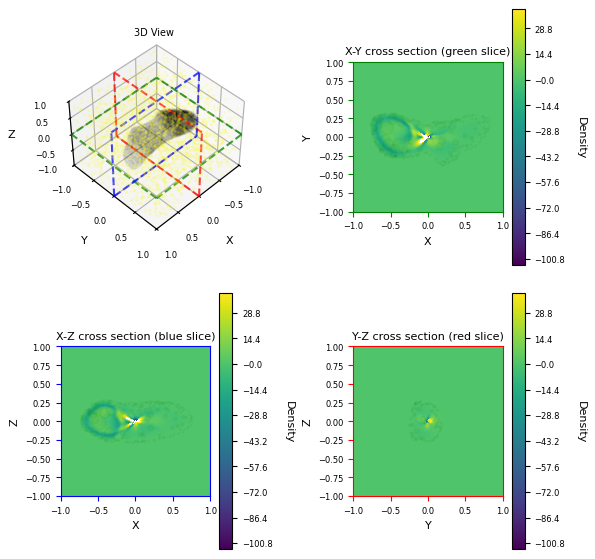

In [24]:
plot_pinn_vs_mascon_contours(net, model.coords, model.masses.unsqueeze(1), heatmap=True, progressbar=True);